In [4]:
import pandas as pd

In [4]:
df = pd.read_csv('resources/car_init.csv', sep=';')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   startLon   500 non-null    float64
 1   startLat   500 non-null    float64
 2   destLon    500 non-null    float64
 3   destLat    500 non-null    float64
 4   driveMode  1000 non-null   int64  
 5   maxSpeed   1000 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 47.0 KB


In [12]:
df.groupby(['startLon','startLat']).size().reset_index().rename(columns={0:'count'})

,startLon,startLat,count
0,31.482268,-24.979422,50
1,31.534930,-25.460457,100
2,31.591958,-24.994678,150
3,31.779859,-24.389864,50
4,31.894040,-25.362301,100
5,31.915333,-25.115829,50


In [14]:
df.groupby(['destLon','destLat']).size().reset_index().rename(columns={0:'count'})

,destLon,destLat,count
0,31.482268,-24.979422,50
1,31.534930,-25.460457,100
2,31.591958,-24.994678,150
3,31.779859,-24.389864,50
4,31.894040,-25.362301,100
5,31.915333,-25.115829,50


In [15]:
df.groupby(['startLon','startLat', 'destLon','destLat']).size().reset_index().rename(columns={0:'count'})

,startLon,startLat,destLon,destLat,count
0,31.482268,-24.979422,31.591958,-24.994678,50
1,31.534930,-25.460457,31.591958,-24.994678,50
2,31.534930,-25.460457,31.915333,-25.115829,50
3,31.591958,-24.994678,31.482268,-24.979422,50
4,31.591958,-24.994678,31.534930,-25.460457,50
5,31.591958,-24.994678,31.894040,-25.362301,50
6,31.779859,-24.389864,31.894040,-25.362301,50
7,31.894040,-25.362301,31.591958,-24.994678,50
8,31.894040,-25.362301,31.779859,-24.389864,50
9,31.915333,-25.115829,31.534930,-25.460457,50


<AxesSubplot:>

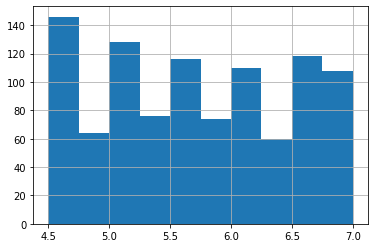

In [35]:
df['maxSpeed'].hist()

In [1]:
from shapely.geometry import Point
from shapely.geometry import MultiPoint


# lon, lat
gateways = [
    Point(31.482268, -24.979422),
    Point(31.534930, -25.460457),
    Point(31.591958, -24.994678),
    Point(31.779859, -24.389864),
    Point(31.894040, -25.362301),
    Point(31.915333, -25.115829),
]

# test points
gateways = [
    Point(31.3124044, -22.4486818),
    Point(31.0835867, -22.4402731),
    Point(31.0446678, -22.7104647),
]


In [2]:
gateways[0].wkt

'POINT (31.3124044 -22.4486818)'

In [5]:
scheduler_rows = []

for source in gateways:

    target_list = []

    for target in gateways:
        if source is not target:
            target_list.append(target)

    mp = MultiPoint(target_list)

    scheduler_rows.append({
        'startTime': '0:00',
        'endTime': '23:00',
        'spawningIntervalInMinutes': 1,
        'spawningAmount': 1,
        'source': source.wkt,
        'destination': mp.wkt
    })

scheduler_df = pd.DataFrame(scheduler_rows)
scheduler_df.to_csv('tourist_scheduler.csv', index=False)

In [6]:
scheduler_df

,startTime,endTime,spawningIntervalInMinutes,spawningAmount,source,destination
0,0:00,23:00,1,1,POINT (31.3124044 -22.4486818),"MULTIPOINT (31.0835867 -22.4402731, 31.0446678..."
1,0:00,23:00,1,1,POINT (31.0835867 -22.4402731),"MULTIPOINT (31.3124044 -22.4486818, 31.0446678..."
2,0:00,23:00,1,1,POINT (31.0446678 -22.7104647),"MULTIPOINT (31.3124044 -22.4486818, 31.0835867..."
